# STEP 1 · 数据审计

站点字段/过滤/年份范围、GPS 质量、随机抽样轨迹、站点与 GPS 空间分布。

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'        # 城市配置键；换城市改这里
CITY_CONFIG = ''          # 可选：外部 city_configs.json 路径
MODE = 'truncated'        # 现状口径：'truncated'(观测期前已建) 或 'comprehensive'(全部现存)
NOTEBOOK_SMOKE = False     # True=少抽样/少天数，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
OUT = cso.OUTPUT_ROOT / cso.CITY / 'notebook_step1'   # 图件输出
OUT.mkdir(parents=True, exist_ok=True)
print(f'城市 {cso.CITY_NAME}({cso.CITY}) | 口径 {MODE} | 抽样 {DRAWS} | 发现 {len(cso.DAYS)} 天')
print(f'参数 C_BAR={cso.C_BAR} d0={cso.D0_DECAY} gamma={cso.GAMMA} u={cso.SYS_UTIL} beta={cso.BETA_CROWD} P_DEAD={cso.P_DEAD}')
print('图件输出目录:', OUT)

城市 广州(guangzhou) | 口径 truncated | 抽样 40 | 发现 7 天
参数 C_BAR=100.0 d0=8.0 gamma=10.0 u=1.0 beta=1.0 P_DEAD=1000.0
图件输出目录: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\ChargingStationOptimization\Outputs\guangzhou\notebook_step1


## 1.1 站点原始字段
建成时间 `create_time`、快慢充桩数、WGS84 坐标字段。

In [2]:
# 全部原始站点行（含 create_time、geo_ok 过滤标记）
raw = cso._load_stations_raw()
print('原始行数:', len(raw), '| 通过 bbox+容量过滤:', int(raw["geo_ok"].sum()))
print('建成时间范围:', pd.to_datetime(raw["create_time"]).min(), '→', pd.to_datetime(raw["create_time"]).max())
display(raw.head(6)); print(raw.dtypes)

原始行数: 3191 | 通过 bbox+容量过滤: 2749
建成时间范围: 2017-11-20 16:08:00 → 2024-08-26 14:44:00


,lon,lat,fast,slow,sid,create_time,geo_ok
0,113.368149,22.989290,286.0,0.0,MA5AU5N17_408,2019-03-19 13:48:00,True
1,113.220249,23.061948,203.0,0.0,MA4UP1U28_GZHS0101,2019-09-19 08:00:00,True
2,113.422384,23.182986,187.0,0.0,101437000_33477,2024-06-18 16:39:00,True
3,113.264506,23.215095,169.0,0.0,395815801_4401110074,2019-02-14 18:34:00,True
4,113.388582,22.907844,152.0,0.0,MA5AK2NB6_61,2021-01-14 08:00:00,True
5,113.302476,23.250086,144.0,0.0,MA59P1AN5_6519,2021-05-02 08:00:00,True


lon                   float64
lat                   float64
fast                  float64
slow                  float64
sid                    object
create_time    datetime64[ns]
geo_ok                   bool
dtype: object


## 1.2 过滤
年份由 `create_time` 发现。存量 = `create_time <= Y-12-31`。

           口径   原始   保留  晚于切点  零容量
    truncated 3191  873  2117  442
comprehensive 3191 2749     0  442
年份范围: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
逐年累计存量: {2017: 88, 2018: 663, 2019: 938, 2020: 1077, 2021: 1586, 2022: 1946, 2023: 2408, 2024: 2749}


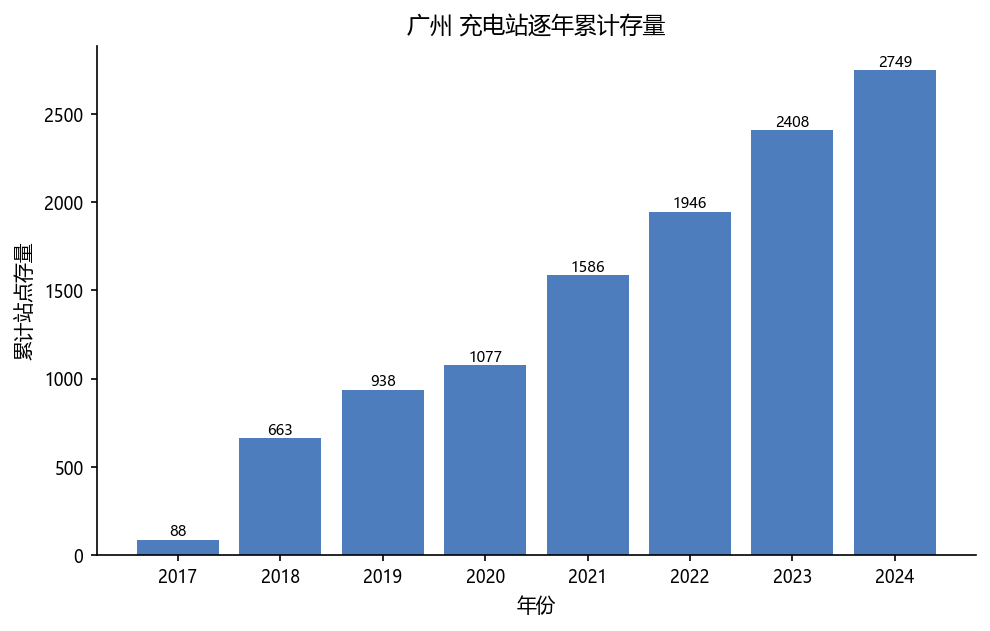

In [3]:
rows = []
for m in ['truncated', 'comprehensive']:
    st, s = cso.load_stations(m, return_stats=True)
    rows.append(dict(口径=m, 原始=s['raw'], 保留=s['kept'], 晚于切点=s['future_create'], 零容量=s['zero_cap']))
print(pd.DataFrame(rows).to_string(index=False))

years = cso.station_years()
cum = {Y: len(cso.station_snapshot(Y)) for Y in years}
print('年份范围:', years)
print('逐年累计存量:', cum)

fig, ax = plt.subplots(figsize=style.mm(120, 70))
ax.bar([str(y) for y in years], [cum[y] for y in years], color=style.C['blue'], alpha=0.9)
for y in years:
    ax.text(str(y), cum[y], str(cum[y]), ha='center', va='bottom', fontsize=7)
ax.set_xlabel('年份'); ax.set_ylabel('累计站点存量'); ax.set_title(f'{cso.CITY_NAME} 充电站逐年累计存量')
style.savefig(fig, OUT / 'fig_station_years.png'); plt.show()

## 1.3 GPS 点数分布与速度分布（多日）

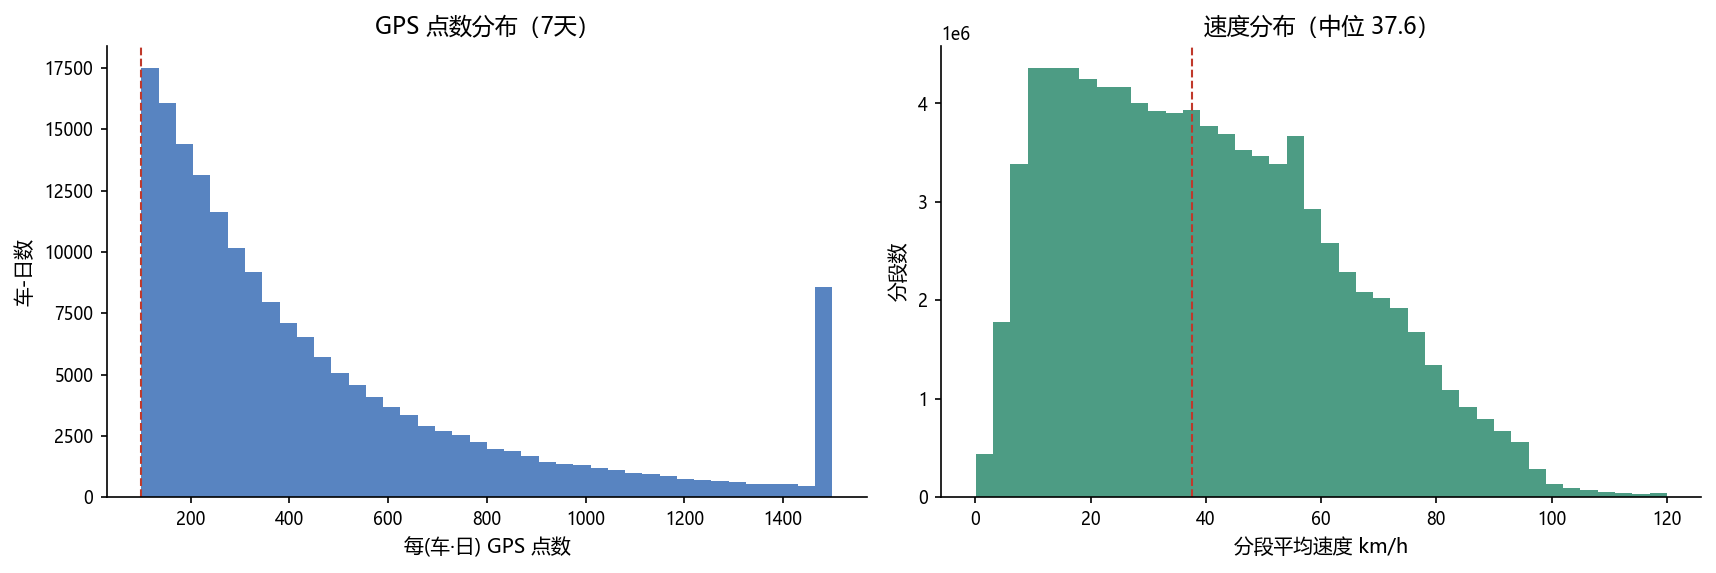

In [4]:
q = cso.gps_quality_summary(smoke=NOTEBOOK_SMOKE)
pts, v = q['points_per_veh_day'], q['seg_speeds']
fig, ax = plt.subplots(1, 2, figsize=style.mm(183, 62))
ax[0].hist(np.clip(pts, 0, 1500), bins=40, color=style.C['blue'], alpha=0.85)
ax[0].axvline(q['min_track_points'], color=style.C['red'], ls='--', lw=1)
ax[0].set_xlabel('每(车·日) GPS 点数'); ax[0].set_ylabel('车-日数'); ax[0].set_title(f'GPS 点数分布（{q["n_days"]}天）')
ax[1].hist(np.clip(v, 0, 120), bins=40, color=style.C['green'], alpha=0.85)
ax[1].axvline(q['speed_median'], color=style.C['red'], ls='--', lw=1)
ax[1].set_xlabel('分段平均速度 km/h'); ax[1].set_ylabel('分段数'); ax[1].set_title(f'速度分布（中位 {q["speed_median"]:.1f}）')
plt.tight_layout(); style.savefig(fig, OUT / 'fig_gps_quality.png'); plt.show()

## 1.4 随机抽样车的完整运行轨迹与SoC

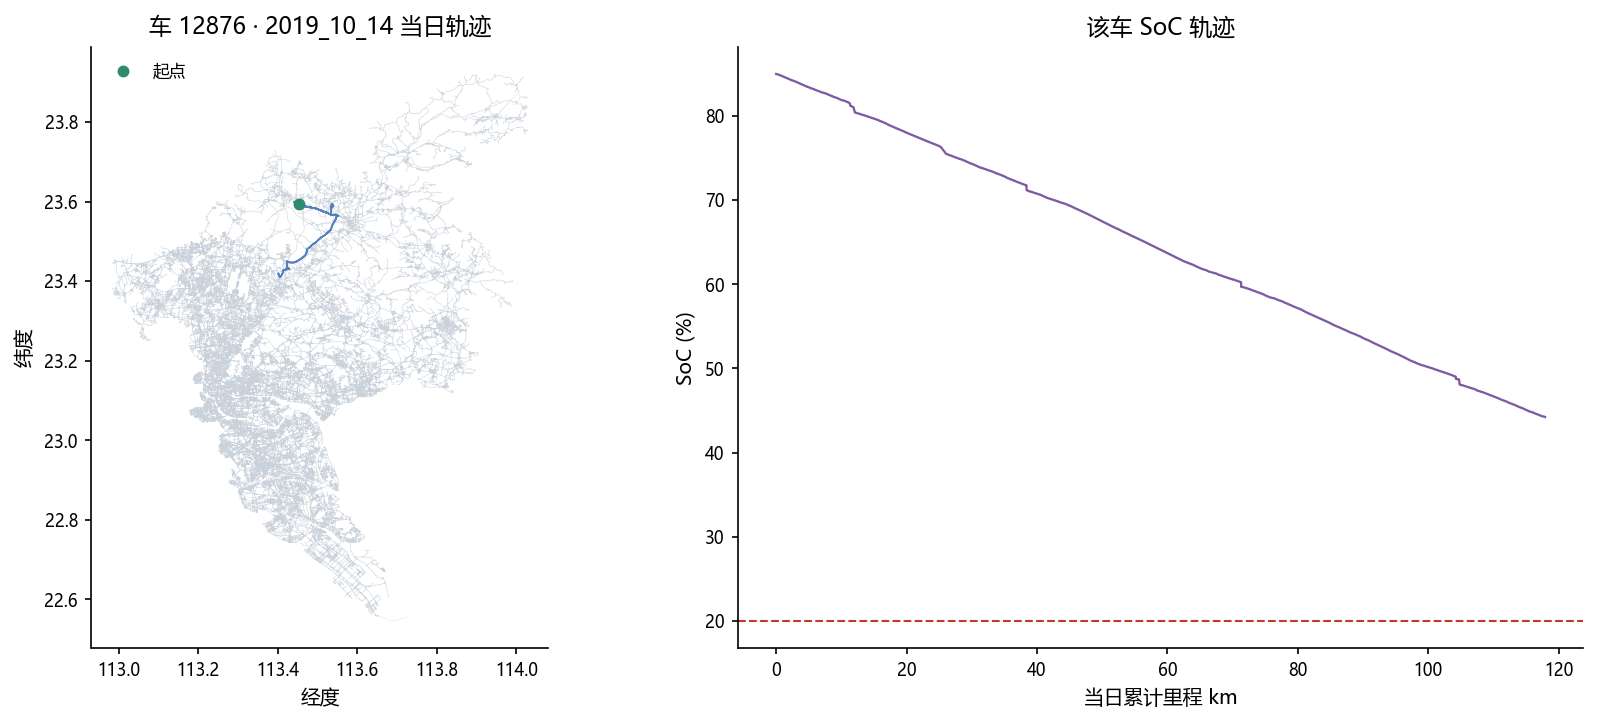

In [5]:
tr = cso.sample_vehicle_trace(seed=cso.SEED)
fig, ax = plt.subplots(1, 2, figsize=style.mm(183, 78))
if not style.draw_network(ax[0], cache_dir=cso.DATA, city=cso.CITY):
    style.draw_admin(ax[0], cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE, color='#7E8795', lw=0.7)
ax[0].plot(tr['lon'], tr['lat'], '-', lw=0.8, color=style.C['blue'], alpha=0.85)
ax[0].scatter(tr['lon'][0], tr['lat'][0], s=22, c=style.C['green'], zorder=5, label='起点')
ax[0].set_title(f'车 {tr["veh"]} · {tr["date"]} 当日轨迹'); ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel('经度'); ax[0].set_ylabel('纬度'); ax[0].legend(loc='best')
ax[1].plot(tr['cum_km'], tr['soc'] * 100, '-', lw=1.1, color=style.C['purple'])
ax[1].axhline(cso.SOC_LOW * 100, color=style.C['red'], ls='--', lw=1)
ax[1].set_xlabel('当日累计里程 km'); ax[1].set_ylabel('SoC (%)'); ax[1].set_title('该车 SoC 轨迹')
plt.tight_layout(); style.savefig(fig, OUT / 'fig_sample_trace.png'); plt.show()

## 1.5 站点与 GPS 轨迹空间分布

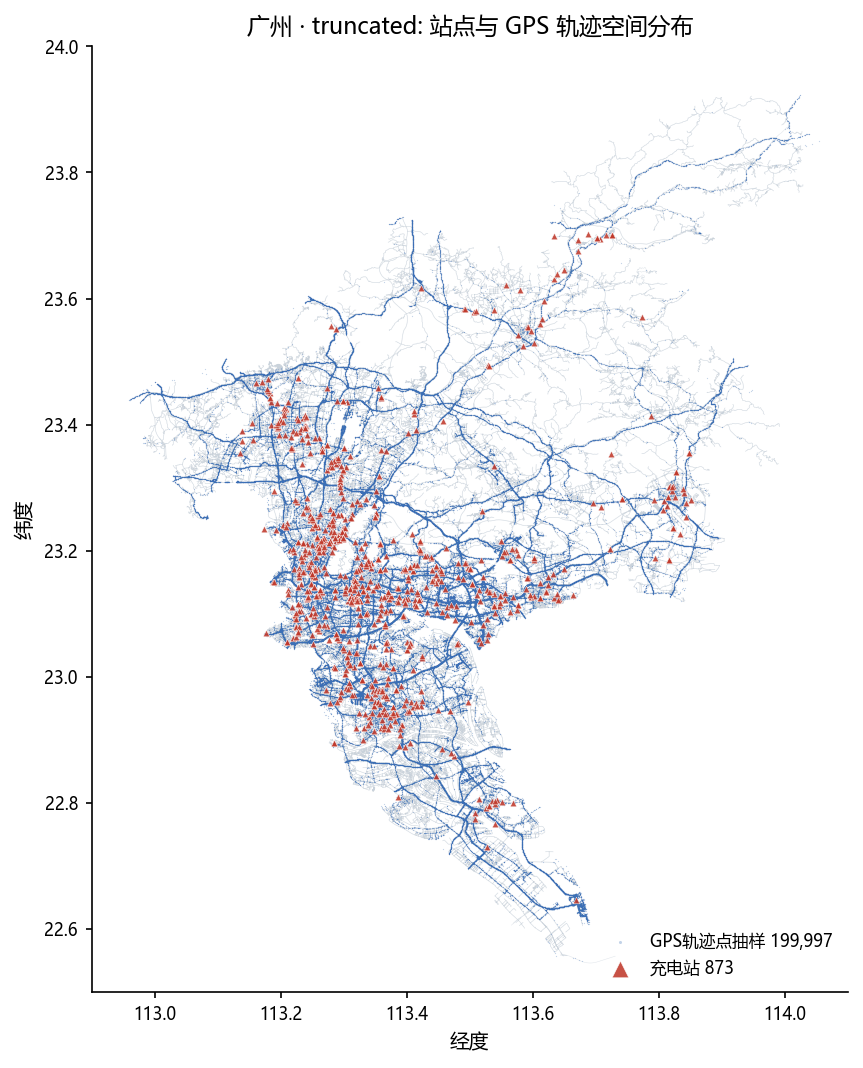

In [6]:
st = cso.load_stations(MODE)
days = cso.DAYS[:1] if NOTEBOOK_SMOKE else cso.DAYS
max_points = 30000 if NOTEBOOK_SMOKE else 200000
per = max(1, max_points // len(days)); rng = np.random.default_rng(cso.SEED)
lons, lats = [], []
for ds, pth in days:
    z = cso.load_segments(ds, pth); n = len(z['lon'])
    idx = rng.choice(n, size=min(per, n), replace=False)
    lons.append(z['lon'][idx]); lats.append(z['lat'][idx])
lon = np.concatenate(lons); lat = np.concatenate(lats)
fig, ax = plt.subplots(figsize=style.mm(130, 130))
if not style.draw_network(ax, cache_dir=cso.DATA, city=cso.CITY):
    style.draw_admin(ax, cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE, color='#7E8795', lw=0.7)
ax.scatter(lon, lat, s=0.35, c=style.C['blue'], alpha=0.30, linewidths=0, rasterized=True, zorder=2, label=f'GPS轨迹点抽样 {len(lon):,}')
ax.scatter(st['lon'], st['lat'], s=10, c=style.C['red'], marker='^', alpha=0.88, edgecolor='white', linewidths=0.25, zorder=4, label=f'充电站 {len(st):,}')
ax.set_xlim(cso.BBOX['lon_min'], cso.BBOX['lon_max']); ax.set_ylim(cso.BBOX['lat_min'], cso.BBOX['lat_max'])
ax.legend(loc='lower right', markerscale=2.5); ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('经度'); ax.set_ylabel('纬度'); ax.set_title(f'{cso.CITY_NAME} · {MODE}: 站点与 GPS 轨迹空间分布')
style.savefig(fig, OUT / 'fig_station_gps.png'); plt.show()